# STA 4155 Final Project: Instagram Post Engagement Rate Analysis

The aim is to analyze the engagement rate of two groups: posts that were made in the morning (6-10AM) and posts that were made in the evening (6-10PM).

**Hypothesis:**

H_0: posting time has no effect on engagement rate.

H_1: posting time affects engagement rate.

**Target Metric:**

Engagement rate.

**Data Collection:**

Dataset from [Kaggle](https://www.kaggle.com/datasets/kundanbedmutha/instagram-analytics-dataset).


In [333]:
# import libraries
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import levene
import matplotlib.pyplot as plt
import seaborn as sns

# Importing & Exploring Data

In [334]:
# import data
data = pd.read_csv('/content/Instagram_Analytics.csv')

data.head()

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,...,5,7,34,4327,6230,0.0385,899,100,7,medium
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,...,10,21,68,7451,8268,0.0663,805,122,5,viral
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,...,2,1,22,1639,2616,0.0531,758,115,8,high
3,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,...,0,7,0,2877,3171,0.0309,402,115,7,medium
4,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,...,8,5,21,5350,8503,0.0221,155,112,9,low


In [335]:
data.info()
# no missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   post_id                   29999 non-null  object 
 1   account_id                29999 non-null  int64  
 2   account_type              29999 non-null  object 
 3   follower_count            29999 non-null  int64  
 4   media_type                29999 non-null  object 
 5   content_category          29999 non-null  object 
 6   traffic_source            29999 non-null  object 
 7   has_call_to_action        29999 non-null  int64  
 8   post_datetime             29999 non-null  object 
 9   post_date                 29999 non-null  object 
 10  post_hour                 29999 non-null  int64  
 11  day_of_week               29999 non-null  object 
 12  likes                     29999 non-null  int64  
 13  comments                  29999 non-null  int64  
 14  shares

In [336]:
data.describe()

,account_id,follower_count,has_call_to_action,post_hour,likes,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count
count,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000
mean,10.567819,10278.305477,0.348778,11.499417,287.653588,8.521917,14.426614,42.517284,6272.475449,8466.952498,0.042107,502.152805,120.081169,7.987933
std,5.763952,6691.862669,0.476592,6.900587,317.647682,10.116505,16.420899,47.808844,4985.877059,6825.900355,0.024095,290.364038,11.009108,2.828130
min,1.000000,3083.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,268.000000,327.000000,0.000000,0.000000,70.000000,0.000000
25%,6.000000,5824.000000,0.000000,6.000000,104.000000,3.000000,5.000000,15.000000,3058.000000,4102.000000,0.024000,251.000000,113.000000,6.000000
50%,11.000000,9044.000000,0.000000,12.000000,199.000000,6.000000,10.000000,29.000000,4913.000000,6595.000000,0.040600,501.000000,120.000000,8.000000
75%,16.000000,10739.000000,1.000000,17.000000,363.000000,11.000000,19.000000,54.000000,7863.000000,10620.500000,0.057000,755.000000,127.000000,10.000000
max,20.000000,31095.000000,1.000000,23.000000,10632.000000,339.000000,516.000000,1542.000000,73339.000000,105203.000000,0.271000,1000.000000,166.000000,21.000000


In [337]:
# define a function to label posting period
def get_posting_period(hour):
    if 6 <= hour <= 10:
        return 'Morning'
    elif 18 <= hour <= 22:
        return 'Evening'
    else:
        return 'Other'

# apply function
data['posting_period'] = data['post_hour'].apply(get_posting_period)

# keep only morning and evening posts
data = data[data['posting_period'].isin(['Morning', 'Evening'])]

print(data['posting_period'].value_counts())

posting_period
Morning    6264
Evening    6240
Name: count, dtype: int64


In [338]:
# bin follower_count into groups
data['follower_group'] = pd.cut(data['follower_count'],
                                 bins=[0, 5000, 10000, 20000, float('inf')],
                                 labels=['Less than 5,000 followers',
                                         'Between 5,000 and 10,000 followers',
                                         'Between 10,000 and 20,000 followers',
                                         'More than 20,000 followers'])

In [339]:
# create separate dataframes
data_morning = data[data['posting_period'] == 'Morning']
data_evening = data[data['posting_period'] == 'Evening']

# Checking Assumptions

In [340]:
# calculate residuals
residuals_morning = data_morning['engagement_rate'] - data_morning['engagement_rate'].mean()
residuals_evening = data_evening['engagement_rate'] - data_evening['engagement_rate'].mean()

residuals = np.concatenate([residuals_morning, residuals_evening])

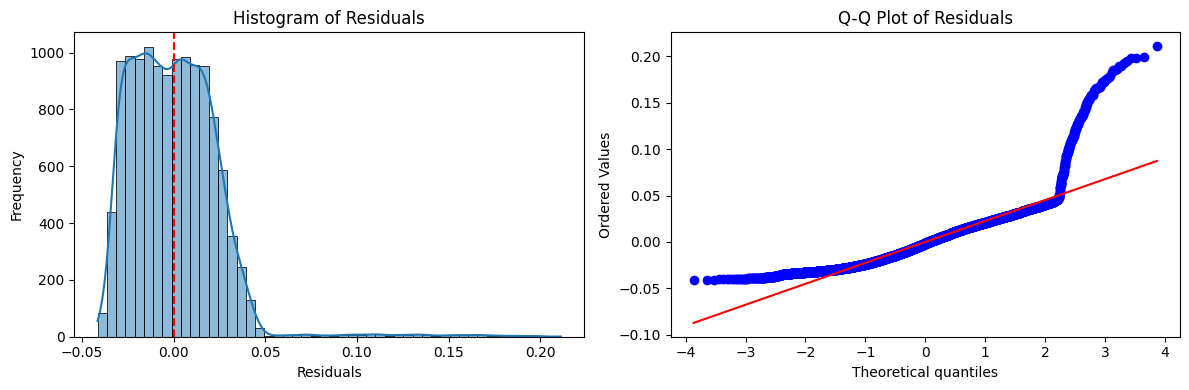

In [341]:
# histogram of residuals

plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
sns.histplot(residuals, bins=50, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Q-Q plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()


# data is right-skewed

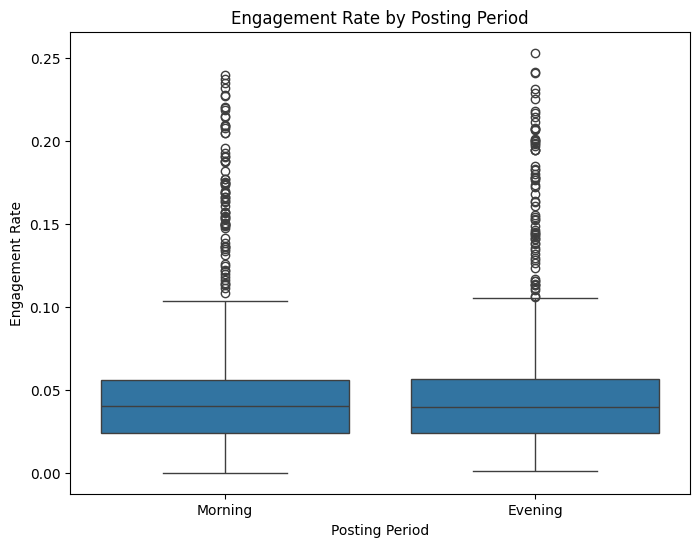

In [342]:
# checking equal variance using box plot
df_combined = pd.DataFrame({
    'engagement_rate': pd.concat([data_morning['engagement_rate'],
                                   data_evening['engagement_rate']]),
    'time': (['Morning'] * len(data_morning)) + (['Evening'] * len(data_evening))
})

plt.figure(figsize=(8,6))
sns.boxplot(data=df_combined, x='time', y='engagement_rate')
plt.title('Engagement Rate by Posting Period')
plt.ylabel('Engagement Rate')
plt.xlabel('Posting Period')
plt.show()

# this supports equal variance

In [343]:
# use Levene's test to check equal variance
stat, p = levene(data_morning['engagement_rate'], data_evening['engagement_rate'])
print(f"Levene's test: statistic={stat:.4f}, p={p:.4f}")

# with p > 0.05, variances are equal

Levene's test: statistic=0.1488, p=0.6997


## Trying Log Transformation

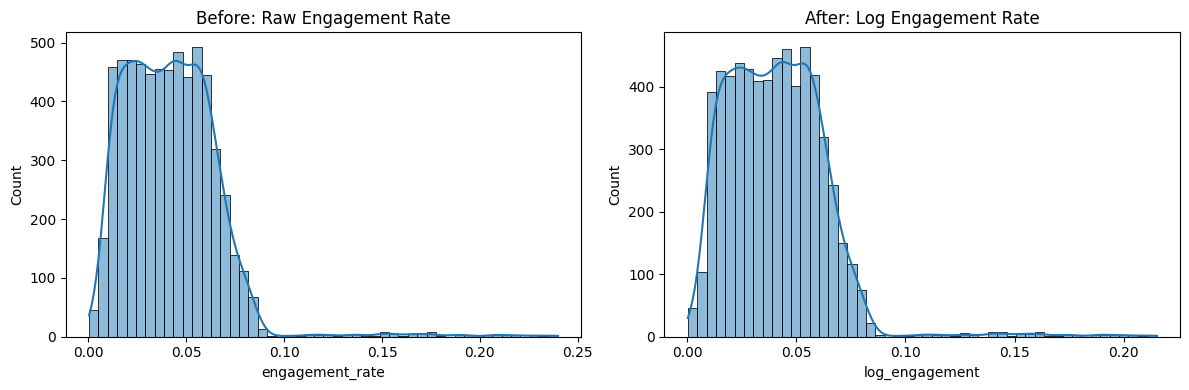

In [344]:
data['log_engagement'] = np.log1p(data['engagement_rate'])

data_morning = data[data['posting_period'] == 'Morning']
data_evening = data[data['posting_period'] == 'Evening']

log_morning = data_morning['log_engagement']
log_evening = data_evening['log_engagement']

# plot comparison
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(data_morning['engagement_rate'], bins=50, kde=True)
plt.title('Before: Raw Engagement Rate')

plt.subplot(1, 2, 2)
sns.histplot(log_morning, bins=50, kde=True)
plt.title('After: Log Engagement Rate')

plt.tight_layout()
plt.show()

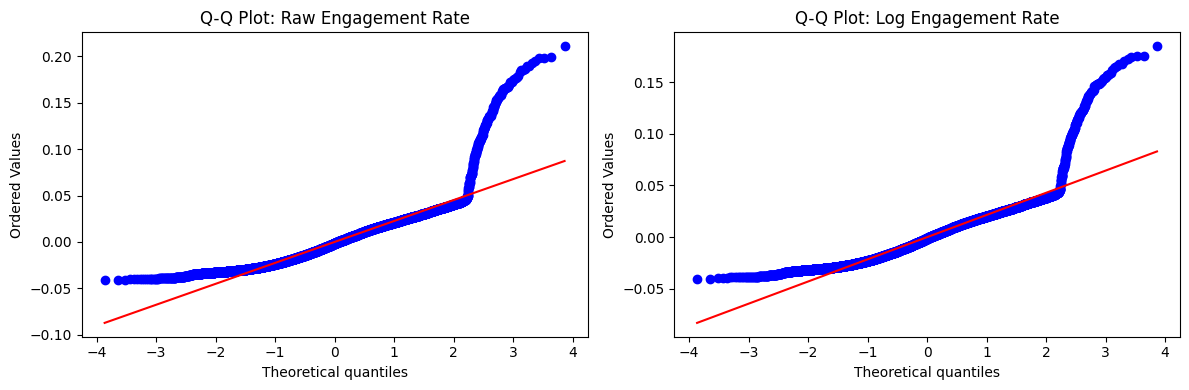

In [345]:
# Q-Q plot of log-transformed residuals
log_residuals_morning = log_morning - log_morning.mean()
log_residuals_evening = log_evening - log_evening.mean()
log_residuals = np.concatenate([log_residuals_morning, log_residuals_evening])

plt.figure(figsize=(12, 4))

# before
plt.subplot(1, 2, 1)
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot: Raw Engagement Rate')

# after
plt.subplot(1, 2, 2)
stats.probplot(log_residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot: Log Engagement Rate')

plt.tight_layout()
plt.show()

Almost no difference, use non-transformed data

# Two-Sample t-Test

In [346]:
# two-sample t-test
t_stats, p_value = stats.ttest_ind(a=data_morning['engagement_rate'], b=data_evening['engagement_rate'], equal_var=True)

print('T-statistic of the test is:', t_stats)
print(f'p_value: {p_value:.4f}')

alpha = 0.05
if p_value >= alpha:
    print('Posting time has no effect on engagement rate.')
else:
    print('Posting time has an effect on engagement rate.')

T-statistic of the test is: -0.26550809636555994
p_value: 0.7906
Posting time has no effect on engagement rate.


## Stratifying on content category

In [347]:
# see what content types exist
print(data['content_category'].unique())

['Technology' 'Photography' 'Food' 'Fitness' 'Beauty' 'Music' 'Travel'
 'Lifestyle' 'Comedy' 'Fashion']


In [348]:
# corrected threshold = 0.05 / number of tests
bonferroni_threshold = 0.05 / 10
print(f"Bonferroni corrected threshold: {bonferroni_threshold}\n")

# run a t-test for each content type
for content in data['content_category'].unique():
    morning = data_morning[data_morning['content_category'] == content]['engagement_rate']
    evening = data_evening[data_evening['content_category'] == content]['engagement_rate']

    # use equal_var=False because t-testing on subgroups
    stat, p = stats.ttest_ind(morning, evening, equal_var=False)
    print(f"{content}: t={stat:.4f}, p={p:.4f}, n_morning={len(morning)}, n_evening={len(evening)}")
    if p <= bonferroni_threshold:
        print("Statistically significant.\n")
    else:
        print("Not statistically significant.\n")

# no test is statistically significant according to the corrected threshold

Bonferroni corrected threshold: 0.005

Technology: t=1.0889, p=0.2764, n_morning=628, n_evening=598
Not statistically significant.

Photography: t=-1.9691, p=0.0492, n_morning=652, n_evening=640
Not statistically significant.

Food: t=-0.3136, p=0.7539, n_morning=657, n_evening=659
Not statistically significant.

Fitness: t=-1.3434, p=0.1794, n_morning=612, n_evening=637
Not statistically significant.

Beauty: t=0.9858, p=0.3244, n_morning=608, n_evening=590
Not statistically significant.

Music: t=-1.3731, p=0.1700, n_morning=622, n_evening=617
Not statistically significant.

Travel: t=1.8759, p=0.0609, n_morning=612, n_evening=643
Not statistically significant.

Lifestyle: t=0.3969, p=0.6915, n_morning=632, n_evening=634
Not statistically significant.

Comedy: t=1.4145, p=0.1575, n_morning=605, n_evening=604
Not statistically significant.

Fashion: t=-1.5893, p=0.1122, n_morning=636, n_evening=618
Not statistically significant.



## Stratifying on follower count

In [349]:
# corrected threshold = 0.05 / number of tests
bonferroni_threshold = 0.05 / 4
print(f"Bonferroni corrected threshold: {bonferroni_threshold}\n")

# run t-test for each follower group
for group in ['Less than 5,000 followers', 'Between 5,000 and 10,000 followers', 'Between 10,000 and 20,000 followers', 'More than 20,000 followers']:
    morning = data_morning[data_morning['follower_group'] == group]['engagement_rate']
    evening = data_evening[data_evening['follower_group'] == group]['engagement_rate']

    # use equal_var=False because t-testing on subgroups
    stat, p = stats.ttest_ind(morning, evening, equal_var=False)
    print(f"{group}: t={stat:.4f}, p={p:.4f}, n_morning={len(morning)}, n_evening={len(evening)}")
    if p <= bonferroni_threshold:
        print("Statistically significant.\n")
    else:
        print("Not statistically significant.\n")


# no test is statistically significant according to the corrected threshold

Bonferroni corrected threshold: 0.0125

Less than 5,000 followers: t=0.4415, p=0.6589, n_morning=1588, n_evening=1568
Not statistically significant.

Between 5,000 and 10,000 followers: t=-0.6493, p=0.5162, n_morning=2201, n_evening=2188
Not statistically significant.

Between 10,000 and 20,000 followers: t=0.4332, p=0.6649, n_morning=1870, n_evening=1880
Not statistically significant.

More than 20,000 followers: t=-1.2502, p=0.2115, n_morning=605, n_evening=604
Not statistically significant.



## Stratifying on content category and follower count

In [350]:
# corrected threshold = 0.05 / number of tests
bonferroni_threshold = 0.05 / 40
print(f"Bonferroni corrected threshold: {bonferroni_threshold}\n")

for content in data['content_category'].unique():
    for group in ['Less than 5,000 followers', 'Between 5,000 and 10,000 followers', 'Between 10,000 and 20,000 followers', 'More than 20,000 followers']:
        morning = data_morning[(data_morning['content_category'] == content) &
                               (data_morning['follower_group'] == group)]['engagement_rate']
        evening = data_evening[(data_evening['content_category'] == content) &
                               (data_evening['follower_group'] == group)]['engagement_rate']

        # use equal_var=False because t-testing on subgroups
        stat, p = stats.ttest_ind(morning, evening, equal_var=False)
        print(f"{content} | {group}: t={stat:.4f}, p={p:.4f}, n_morning={len(morning)}, n_evening={len(evening)}")
        if p <= bonferroni_threshold:
          print("Statistically significant.\n")
        else:
          print("Not statistically significant.\n")

# no test is statistically significant according to the corrected threshold

Bonferroni corrected threshold: 0.00125

Technology | Less than 5,000 followers: t=-0.1892, p=0.8501, n_morning=141, n_evening=152
Not statistically significant.

Technology | Between 5,000 and 10,000 followers: t=0.6700, p=0.5032, n_morning=244, n_evening=203
Not statistically significant.

Technology | Between 10,000 and 20,000 followers: t=0.3850, p=0.7005, n_morning=195, n_evening=185
Not statistically significant.

Technology | More than 20,000 followers: t=2.0319, p=0.0448, n_morning=48, n_evening=58
Not statistically significant.

Photography | Less than 5,000 followers: t=-1.6954, p=0.0911, n_morning=166, n_evening=159
Not statistically significant.

Photography | Between 5,000 and 10,000 followers: t=-1.4593, p=0.1452, n_morning=217, n_evening=221
Not statistically significant.

Photography | Between 10,000 and 20,000 followers: t=0.3290, p=0.7423, n_morning=207, n_evening=187
Not statistically significant.

Photography | More than 20,000 followers: t=-1.3501, p=0.1793, n_morn